In [3]:
import pandas as pd 
import numpy as np

In [4]:
customer = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_customers_dataset.csv')
geo = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_geolocation_dataset.csv')
order_iteam = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_order_items_dataset.csv')
order_payment =pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_order_payments_dataset.csv')
order_review = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_order_reviews_dataset.csv')
order_dataset = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_orders_dataset.csv')
product = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_products_dataset.csv')
seller = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\olist_sellers_dataset.csv')
product_category = pd.read_csv(r'C:\Users\rajpu\Downloads\olist_dataset.csv\product_category_name_translation.csv')

In [5]:
datasets = {
    'customer': customer,
    'geo': geo,
    'order_iteam': order_iteam,
    'order_payment': order_payment,
    'order_review': order_review,
    'order_dataset': order_dataset,
    'product': product,
    'seller': seller,
    'product_category': product_category
}

In [6]:
for name, df in datasets.items():

    print(f"\n{name.upper()}")
    print("-"*50)

    print(df.head())

    print("\nShape:")
    print(df.shape)

    print("\nInfo:")
    print(df.info())

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicates:")
    print(df.duplicated().sum())


CUSTOMER
--------------------------------------------------
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Shape:
(99441, 5)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
D

In [7]:
order_dataset.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [8]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

In [9]:
for col in date_columns:
    order_dataset[col] = pd.to_datetime(order_dataset[col])

In [10]:
order_iteam.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [11]:
order_iteam['shipping_limit_date'] = pd.to_datetime(
    order_iteam['shipping_limit_date']
)

In [12]:
order_iteam.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


# Delivery Time Calculate

In [13]:
order_dataset['delivery_days'] = (
    order_dataset['order_delivered_customer_date']
    - order_dataset['order_purchase_timestamp']
).dt.days

# Purchase Year Extract

In [ ]:
order_dataset['purchase_year'] = (
    order_dataset['order_purchase_timestamp'].dt.year
)

# Purchase Month Extract

In [ ]:
order_dataset['purchase_month'] = (
    order_dataset['order_purchase_timestamp'].dt.month
)

# Day Name Extract

In [ ]:
order_dataset['purchase_day'] = (
    order_dataset['order_purchase_timestamp'].dt.day_name()
)

# Hour Extract

In [ ]:
order_dataset['purchase_hour'] = (
    order_dataset['order_purchase_timestamp'].dt.hour
)

# Weekend vs Weekday

In [ ]:
order_dataset['is_weekend'] = (
    order_dataset['order_purchase_timestamp'].dt.dayofweek >= 5
)

## Delivery Time Distribution

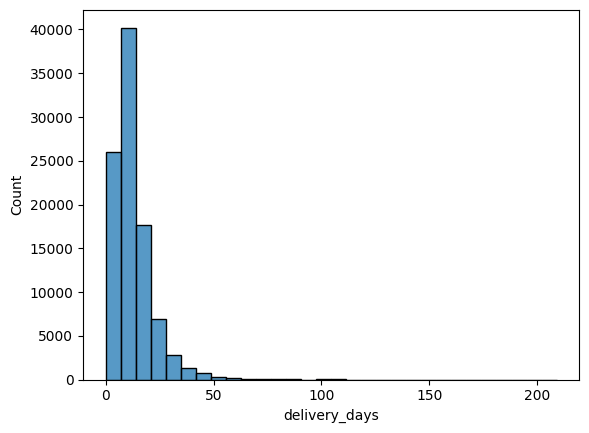

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(order_dataset['delivery_days'], bins=30)
plt.show()

### Orders per Month

In [ ]:
order_dataset['purchase_month'].value_counts().sort_index()

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: count, dtype: int64

### Orders by Hour

In [ ]:
order_dataset['purchase_hour'].value_counts().sort_index()

purchase_hour
0     2394
1     1170
2      510
3      272
4      206
5      188
6      502
7     1231
8     2967
9     4785
10    6177
11    6578
12    5995
13    6518
14    6569
15    6454
16    6675
17    6150
18    5769
19    5982
20    6193
21    6217
22    5816
23    4123
Name: count, dtype: int64

### Orders + Customers Merge

In [14]:
orders_customers = pd.merge(
    order_dataset,
    customer,
    on='customer_id',
    how='left'
)

orders_customers.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


### Orders + Payments Merge

In [15]:
orders_payments = pd.merge(
    order_dataset,
    order_payment,
    on='order_id',
    how='left'
)

orders_payments.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1.0,credit_card,3.0,179.12


### Orders + Order Items Merge

In [16]:
orders_items = pd.merge(
    order_dataset,
    order_iteam,
    on='order_id',
    how='left'
)

orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


### Full Main Dataset

In [17]:
full_data = order_dataset.merge(
    customer,
    on='customer_id',
    how='left'
).merge(
    order_iteam,
    on='order_id',
    how='left'
).merge(
    order_payment,
    on='order_id',
    how='left'
).merge(
    product,
    on='product_id',
    how='left'
)

full_data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,customer_unique_id,...,payment_installments,payment_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,1.0,18.12,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,1.0,2.00,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,7c396fd4830fd04220f754e42b4e5bff,...,1.0,18.59,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,af07308b275d755c9edb36a90c618231,...,1.0,141.46,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,3a653a41f6f9fc3d2a113cf8398680e8,...,3.0,179.12,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0


# Top Selling Categories

In [18]:
full_data['product_category_name'].value_counts().head(10)

product_category_name
cama_mesa_banho           11823
beleza_saude               9975
esporte_lazer              8945
moveis_decoracao           8744
informatica_acessorios     8082
utilidades_domesticas      7355
relogios_presentes         6201
telefonia                  4721
ferramentas_jardim         4574
automotivo                 4379
Name: count, dtype: int64

In [22]:
! pip install matplotlib


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import matplotlib.pyplot as plt

## Top Selling Categories

In [26]:
full_data['product_category_name'].value_counts().head(10)

product_category_name
cama_mesa_banho           11823
beleza_saude               9975
esporte_lazer              8945
moveis_decoracao           8744
informatica_acessorios     8082
utilidades_domesticas      7355
relogios_presentes         6201
telefonia                  4721
ferramentas_jardim         4574
automotivo                 4379
Name: count, dtype: int64

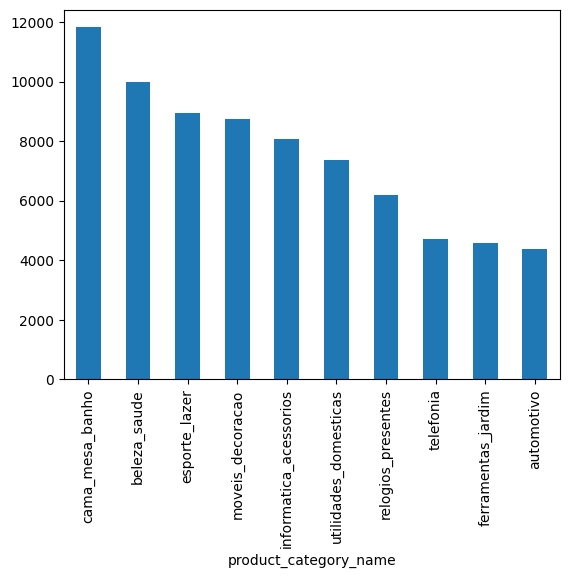

In [28]:
full_data['product_category_name'].value_counts().head(10).plot(
    kind='bar'
)

plt.show()

## Monthly Orders Trend

In [31]:
order_dataset['purchase_month'] = (
    order_dataset['order_purchase_timestamp'].dt.month
)

In [32]:
order_dataset.groupby('purchase_month')['order_id'].count()

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
Name: order_id, dtype: int64

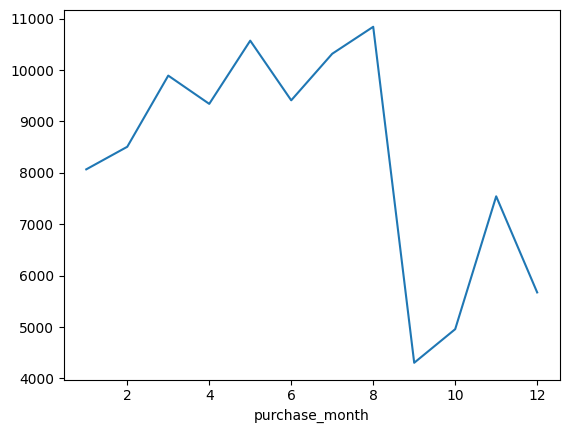

In [33]:
order_dataset.groupby('purchase_month')['order_id'].count().plot(
    kind='line'
)

plt.show()

## Average Delivery Time

In [34]:
order_dataset['delivery_days'].mean()

np.float64(12.094085575687217)

## Orders by Hour

In [36]:
order_dataset['purchase_hour'] = (
    order_dataset['order_purchase_timestamp'].dt.hour
)

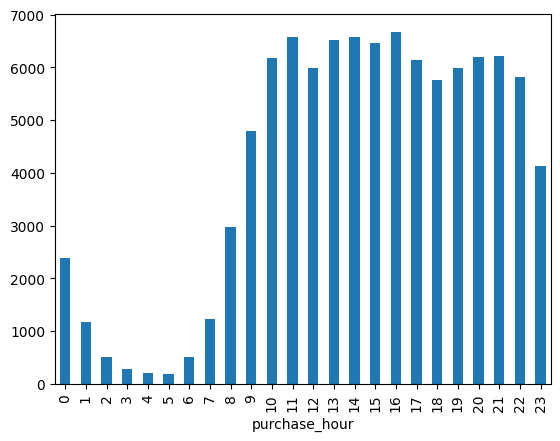

In [37]:
order_dataset['purchase_hour'].value_counts().sort_index().plot(
    kind='bar'
)

plt.show()

## Weekend vs Weekday Orders

In [39]:
order_dataset['is_weekend'] = (
    order_dataset['order_purchase_timestamp'].dt.dayofweek >= 5
)

In [40]:
order_dataset['is_weekend'].value_counts()

is_weekend
False    76594
True     22847
Name: count, dtype: int64

## Highest Payment Type

In [41]:
order_payment['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

## Top States by Orders

In [42]:
orders_customers['customer_state'].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64